<a href="https://colab.research.google.com/github/Laahir/MAT-422/blob/main/MAT422_HW2_Section_2_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Laahir/MAT-422/blob/main/MAT422_HW2_Section_2_4.ipynb)

# MAT 422 - Homework 2 - Section 2.4: MLE and Linear Regression

**Name:** Laahir
**Course:** MAT 422
**Topics covered:** maximum likelihood estimation (MLE) for random samples, linear regression

Same deal as my other homeworks, I'm using stuff from my tutoring job since that's data I actually get. Quiz pass rates and exam scores show up constantly when I'm helping students, so they work well here.

In [1]:
import numpy as np
from scipy import stats, optimize
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 2.4.1 MLE for Random Samples

Here's the idea in plain words. Say you have some data and you think it came from a certain kind of distribution, but you don't know the parameter (like the probability of success, or the mean). Maximum likelihood says: pick the parameter value that makes the data you actually saw as likely as possible.

The likelihood is just the probability of the whole sample, treated as a function of the parameter. Since a sample is independent draws, the likelihood is a product of a bunch of small numbers, which gets messy, so we usually work with the log of it (the log-likelihood). The log turns the product into a sum and the max stays in the same spot.

I'll do two examples. First a yes/no one (Bernoulli), then a bell curve one (Normal).

### Example 1: quiz pass rate (Bernoulli)

Say 25 students took a quiz and 17 passed. Each student either passes (1) or fails (0), and I'll assume they're independent with the same pass probability p. I want the MLE of p.

For k passes out of n students the log-likelihood is `k * log(p) + (n - k) * log(1 - p)`. Setting the derivative to zero gives p = k / n. So the math says the answer should just be 17/25 = 0.68. Let's check that by brute force.

In [2]:
n_students = 25
n_passed = 17

p_grid = np.linspace(0.01, 0.99, 500)
log_likelihood = n_passed * np.log(p_grid) + (n_students - n_passed) * np.log(1 - p_grid)

p_mle_formula = n_passed / n_students
p_mle_from_grid = p_grid[np.argmax(log_likelihood)]

print("MLE from the formula k/n:", p_mle_formula)
print("p that maximizes the log-likelihood on a grid:", p_mle_from_grid)
print("close enough?", np.isclose(p_mle_formula, p_mle_from_grid, atol=0.01))

MLE from the formula k/n: 0.68
p that maximizes the log-likelihood on a grid: 0.6796993987975952
close enough? True


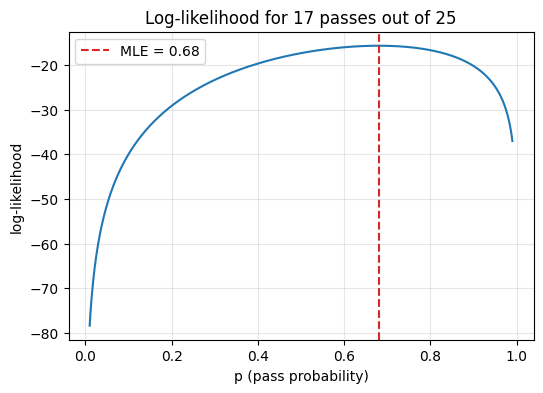

In [3]:
plt.figure(figsize=(6, 4))
plt.plot(p_grid, log_likelihood, color="tab:blue")
plt.axvline(p_mle_formula, color="tab:red", linestyle="--", label=f"MLE = {p_mle_formula}")
plt.xlabel("p (pass probability)")
plt.ylabel("log-likelihood")
plt.title("Log-likelihood for 17 passes out of 25")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The curve peaks right at 0.68, which is exactly the fraction of students who passed. It kind of makes sense, if 68% of the sample passed, then a pass probability of 0.68 explains that sample better than any other number does. The curve also drops off fast on both sides, which tells me the data really does point at a pretty specific range for p.

### Example 2: exam scores (Normal)

Now say I have 30 exam scores and I'm modeling them as Normal with unknown mean and standard deviation. The MLE math works out to:

- the MLE of the mean is the sample mean
- the MLE of the variance is the average of the squared deviations, dividing by n

That second one is a little different from the usual sample variance, which divides by n - 1. The MLE version divides by n, so it comes out a tiny bit smaller. I'll compute both so I can see the difference, and I'll also have the computer find the MLE numerically without using my formulas, as a check.

In [4]:
np.random.seed(5)
scores = np.random.normal(76, 9, 30).round(1)

mu_mle = scores.mean()
sigma_mle = np.sqrt(np.mean((scores - mu_mle) ** 2))     # divides by n
sigma_unbiased = scores.std(ddof=1)                      # divides by n - 1

print("sample mean (MLE of mu):", mu_mle)
print("sigma MLE (divide by n):", sigma_mle)
print("sigma with n - 1:", sigma_unbiased)

sample mean (MLE of mu): 75.74
sigma MLE (divide by n): 8.546562661873681
sigma with n - 1: 8.692668333637302


In [5]:
# check 1: scipy's built-in fit should match my formulas
mu_scipy, sigma_scipy = stats.norm.fit(scores)
print("scipy norm.fit gives:", mu_scipy, sigma_scipy)

# check 2: minimize the negative log-likelihood directly, no formulas at all
def neg_log_likelihood(params):
    mu, log_sigma = params
    sigma = np.exp(log_sigma)      # exp keeps sigma positive
    return -np.sum(stats.norm.logpdf(scores, mu, sigma))

result = optimize.minimize(neg_log_likelihood, x0=[60, np.log(5)])
mu_numeric = result.x[0]
sigma_numeric = np.exp(result.x[1])
print("numerical optimizer gives:", mu_numeric, sigma_numeric)

print("\nall three agree?",
      np.allclose([mu_mle, sigma_mle], [mu_scipy, sigma_scipy]) and
      np.allclose([mu_mle, sigma_mle], [mu_numeric, sigma_numeric], atol=1e-3))

scipy norm.fit gives: 75.74 8.546562661873681
numerical optimizer gives: 75.74000203612583 8.546562816991145

all three agree? True


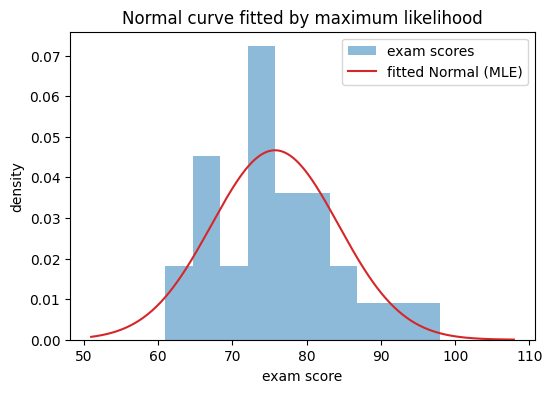

In [6]:
x_vals = np.linspace(scores.min() - 10, scores.max() + 10, 300)

plt.figure(figsize=(6, 4))
plt.hist(scores, bins=10, density=True, color="tab:blue", alpha=0.5, label="exam scores")
plt.plot(x_vals, stats.norm.pdf(x_vals, mu_mle, sigma_mle), color="tab:red", label="fitted Normal (MLE)")
plt.xlabel("exam score")
plt.ylabel("density")
plt.title("Normal curve fitted by maximum likelihood")
plt.legend()
plt.show()

My formulas, scipy, and the optimizer all land on the same mean and standard deviation, so the math checks out. The optimizer never saw my formulas, it just kept nudging mu and sigma until the log-likelihood stopped improving, and it ended up in the same spot. The red curve is the Normal distribution that makes this particular set of scores most likely.

One thing I noticed: sigma with n is a bit smaller than sigma with n - 1. With only 30 scores the gap is small but visible, and it would shrink even more with a bigger sample.

## 2.4.2 Linear Regression

Linear regression fits a line `y = b0 + b1 * x` to data. The cool connection to the last section is that if you assume the noise around the line is Normal, then the MLE for the line is the same as the least squares line. So maximizing the likelihood and minimizing the squared errors turn out to be the same problem.

Here I'll use hours studied (x) and exam score (y) for 20 students. I made the data so the true relationship is roughly score = 52 + 4.5 * hours plus some random noise, so I know what the answer should be close to.

In [7]:
np.random.seed(8)
hours = np.round(np.random.uniform(1, 10, 20), 1)
exam = 52 + 4.5 * hours + np.random.normal(0, 4, 20)

# design matrix: a column of ones for the intercept, then the hours
X = np.column_stack([np.ones_like(hours), hours])

# normal equations: (X^T X) beta = X^T y
beta_hat = np.linalg.solve(X.T @ X, X.T @ exam)
print("intercept b0 =", beta_hat[0])
print("slope b1     =", beta_hat[1])

# check against numpy's own line fit (polyfit returns slope first)
slope_np, intercept_np = np.polyfit(hours, exam, 1)
print("\nnp.polyfit says: intercept =", intercept_np, ", slope =", slope_np)
print("same answer?", np.allclose(beta_hat, [intercept_np, slope_np]))

intercept b0 = 52.683991216961786
slope b1     = 4.405801890070816

np.polyfit says: intercept = 52.683991216961736 , slope = 4.405801890070824
same answer? True


In [8]:
fitted = X @ beta_hat
residuals = exam - fitted

# the MLE of the noise standard deviation (again divides by n)
sigma_hat = np.sqrt(np.mean(residuals ** 2))

# R squared: how much of the variation in scores the line explains
ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((exam - exam.mean()) ** 2)
r_squared = 1 - ss_res / ss_tot

print("noise sigma (MLE) =", sigma_hat)
print("R squared =", r_squared)
print("residuals add up to about zero:", np.isclose(residuals.sum(), 0))

noise sigma (MLE) = 2.987148330368178
R squared = 0.9200831997101335
residuals add up to about zero: True


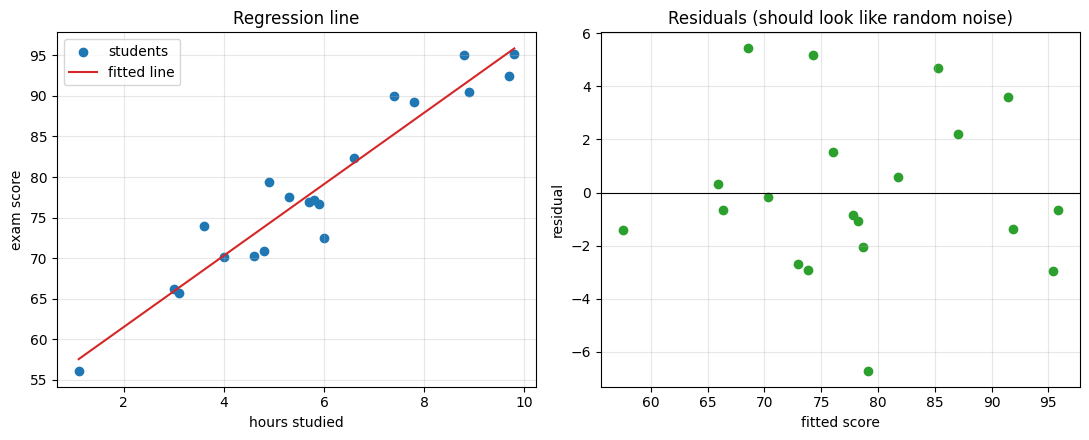

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

x_line = np.linspace(hours.min(), hours.max(), 50)
axes[0].scatter(hours, exam, color="tab:blue", label="students")
axes[0].plot(x_line, beta_hat[0] + beta_hat[1] * x_line, color="tab:red", label="fitted line")
axes[0].set_xlabel("hours studied")
axes[0].set_ylabel("exam score")
axes[0].set_title("Regression line")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(fitted, residuals, color="tab:green")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("fitted score")
axes[1].set_ylabel("residual")
axes[1].set_title("Residuals (should look like random noise)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The line fits well, with an R squared of about 0.92, so hours studied explains most of the variation in exam score in this made up class. The slope is about 4.4, meaning each extra hour of studying goes with roughly 4.4 more points, which is close to the 4.5 I used to build the data. The residual plot looks like a random cloud around zero with no obvious curve or funnel shape, which is what we want to see if a straight line is a reasonable model.

### Checking the MLE connection

Now the part that ties this section together. I'll skip the least squares formula completely and just tell the computer to find the b0, b1, and sigma that maximize the Normal log-likelihood of the data. If the math is right, it should land on the same line.

In [10]:
def neg_log_likelihood_regression(params):
    b0, b1, log_sigma = params
    sigma = np.exp(log_sigma)
    predicted = b0 + b1 * hours
    return -np.sum(stats.norm.logpdf(exam, predicted, sigma))

result = optimize.minimize(
    neg_log_likelihood_regression,
    x0=[0, 0, np.log(5)],
    method="Nelder-Mead",
    options={"maxiter": 5000, "xatol": 1e-8, "fatol": 1e-10},
)

b0_mle, b1_mle = result.x[0], result.x[1]
sigma_mle_reg = np.exp(result.x[2])

print("MLE intercept:", b0_mle, "  least squares intercept:", beta_hat[0])
print("MLE slope:    ", b1_mle, "  least squares slope:    ", beta_hat[1])
print("MLE sigma:    ", sigma_mle_reg, "  residual sigma:         ", sigma_hat)

print("\nMLE and least squares agree?",
      np.allclose([b0_mle, b1_mle, sigma_mle_reg], [beta_hat[0], beta_hat[1], sigma_hat], atol=1e-3))

MLE intercept: 52.68399117695378   least squares intercept: 52.683991216961786
MLE slope:     4.405801886943607   least squares slope:     4.405801890070816
MLE sigma:     2.98714835838035   residual sigma:          2.987148330368178

MLE and least squares agree? True


They match, which is the whole point. Under Normal noise, maximizing the likelihood and minimizing the sum of squared errors give the exact same line. The optimizer started from a terrible guess (a flat line at zero) and still found the least squares answer, so this isn't a coincidence of the starting point. It also gives the same sigma as the residual calculation, which is the MLE that divides by n.

## Reflection and Submission Checklist

- I explained each idea in my own words before the code.
- I checked things numerically instead of just trusting the formulas (the Bernoulli MLE matching k/n, the Normal MLE matching scipy and a numerical optimizer, the normal equations matching polyfit, and the regression MLE matching least squares).
- I used examples from my tutoring job (quiz pass rate, exam scores, hours studied vs exam score).
- I ran every cell top to bottom in Colab with no errors.
- I saved the notebook straight from Google Colab to GitHub so the Open in Colab badge works.